<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**

### **Taller de Programación para el Análisis de Datos**

#### **Clase 18: Aplicación de Privacidad Diferencial para la protección de datos personales**



El objetivo de esta clase es poder utilizar la metodología de la Privacidad Diferencial para la protección de datos con Python.

## **Obtención de datos**

Se toma el conjunto de datos Bank-Loan de Kaggle - https://www.kaggle.com/itsmesunil/bank-loan-modelling - el cual contiene datos que identifican a clientes pertenecientes al Thera Bank en 1999.
El objetivo en prime rlugar es identificar los atributos con casos únicos como identificadores directos.
En segundo lugar, centraremos el análisis mediante al combinación de atributos para detectar si puede derivarse en la re identificación de un individuo.

In [1]:
import kagglehub

path = kagglehub.dataset_download("itsmesunil/bank-loan-modelling")

print("Path to dataset files:", path)

100%|██████████| 331k/331k [00:00<00:00, 93.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/itsmesunil/bank-loan-modelling/versions/1


In [57]:
#se importa la librería
import pandas as pd

data=pd.read_excel("/root/.cache/kagglehub/datasets/itsmesunil/bank-loan-modelling/versions/1/Bank_Personal_Loan_Modelling.xlsx", sheet_name="Data")
data.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [4]:
#dimensiones del conjunto de datos
data.shape

(5000, 14)

In [5]:
data.columns

Index(['ID', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [6]:
#se renombran columnas

data.columns=['ID', 'Age', 'Experience', 'Income', 'ZIP_Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard']

In [7]:
#tipo de datos contenidos
data.dtypes

,0
ID,int64
Age,int64
Experience,int64
Income,int64
ZIP_Code,int64
Family,int64
CCAvg,float64
Education,int64
Mortgage,int64
Personal_Loan,int64


In [8]:
#se verifican cuantos casos no poseen código de actividad
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIP_Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


Realizará todo el análisis descriptivo necesario



## **Anonimización**

**Suponga que el ID dle cliente sea una espcie de CUIT o DNI (identificador único)**.\
Por ello es recomendable anonimizar esta variable, realizandose a continuación.

In [9]:
#se intala el módulo de anonimización
!pip install anonymizedf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.9 MB/s eta 0:00:00


In [10]:
#se importa la librería para anonimización
from anonymizedf.anonymizedf import anonymize

In [11]:
#se anonimiza el CUIT

an = anonymize(data)

an.fake_ids("ID")

,ID,Age,Experience,Income,ZIP_Code,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Fake_ID
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,KWVV43590749087981
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,WPGO81917892866997
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,IBPZ35578533259299
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,FHHF16485969271188
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,HAMQ11519078271075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0,DBRT95690142808965
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0,HDWP98974549370590
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0,KRYL86126636347575
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0,UYSU88429374384740


In [12]:
#se elimina la variable ID real para evitar tener el identificador directo
data=data.drop(['ID'], axis=1)

In [13]:
#se observa
data

,Age,Experience,Income,ZIP_Code,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Fake_ID
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,KWVV43590749087981
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,WPGO81917892866997
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,IBPZ35578533259299
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,FHHF16485969271188
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,HAMQ11519078271075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0,DBRT95690142808965
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0,HDWP98974549370590
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0,KRYL86126636347575
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0,UYSU88429374384740


##**Conteo individual para la identificación directa**

In [14]:
#se cuentan la cantidad de casos por nivel educativo
data.groupby(['Education']).Education.agg('count')

,Education
Education,
1,2096
2,1403
3,1501


Analizada individualmente, no posee casos únicos (sin riesgo)

In [15]:
#se cuentan la cantidad de casos por ZIP_Code
data.groupby(['ZIP_Code']).ZIP_Code.agg('count')

,ZIP_Code
ZIP_Code,
9307,1
90005,5
90007,6
90009,8
90011,3
...,...
96091,4
96094,2
96145,1


Como se observan casos donde existe uno solo, es variable sensible. Se cuentan para ver cuantos casos son riesgosos

In [16]:
ZIP_Code=pd.DataFrame(data.groupby(['ZIP_Code']).ZIP_Code.agg('count'))
ZIP_Code[ZIP_Code['ZIP_Code']==1].count()

,0
ZIP_Code,11


In [17]:
import seaborn as sns
from matplotlib import pyplot as plt

/tmp/ipython-input-3747300875.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a=sns.countplot(x=ZIP_Code['ZIP_Code'], data=ZIP_Code,  order = ZIP_Code['ZIP_Code'].value_counts().index, palette="Set1" )


Text(0, 0.5, 'Individuos por ZIP_Code')

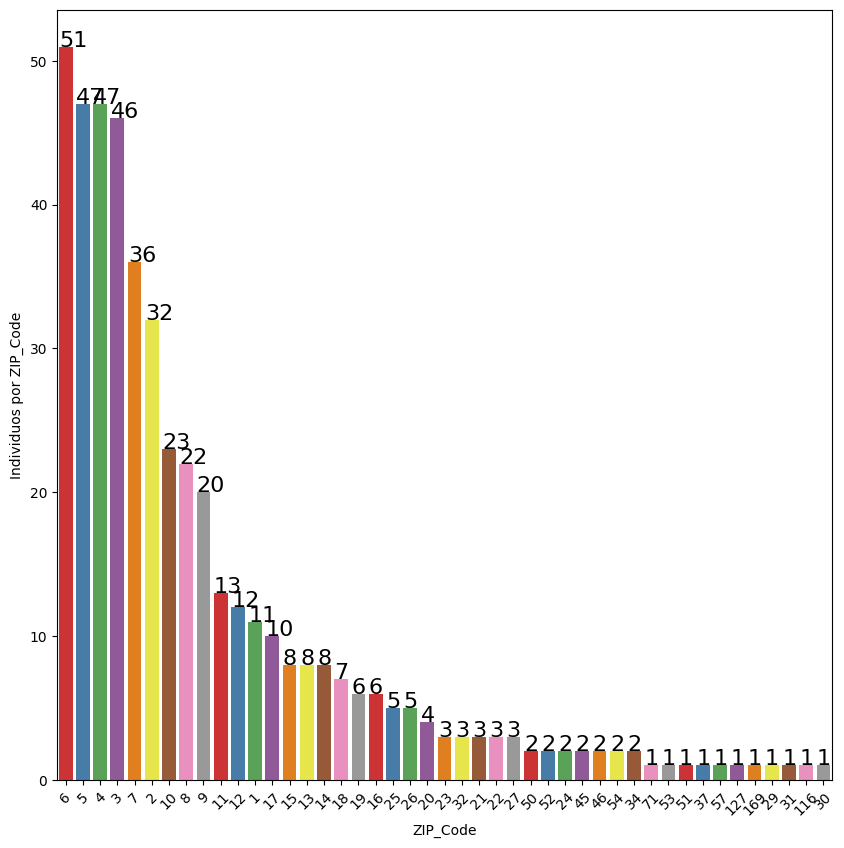

In [18]:
#se visualiza la cantidad de casos por jurisdiccion
plt.figure(figsize=(10,10))

a=sns.countplot(x=ZIP_Code['ZIP_Code'], data=ZIP_Code,  order = ZIP_Code['ZIP_Code'].value_counts().index, palette="Set1" )
a.tick_params(labelsize=10)

for p in a.patches:
   a.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+0.01), fontsize=16)

plt.xticks(rotation=+45)
plt.ylabel("Individuos por ZIP_Code")

Income es variable sensible por poseer casos únicos
ZIP_Code es variable sensible por poseer casos únicos
CCAvg es variable sensible por poseer casos únicos
Mortgage es variable sensible por poseer casos únicos
Fake_ID es variable sensible por poseer casos únicos


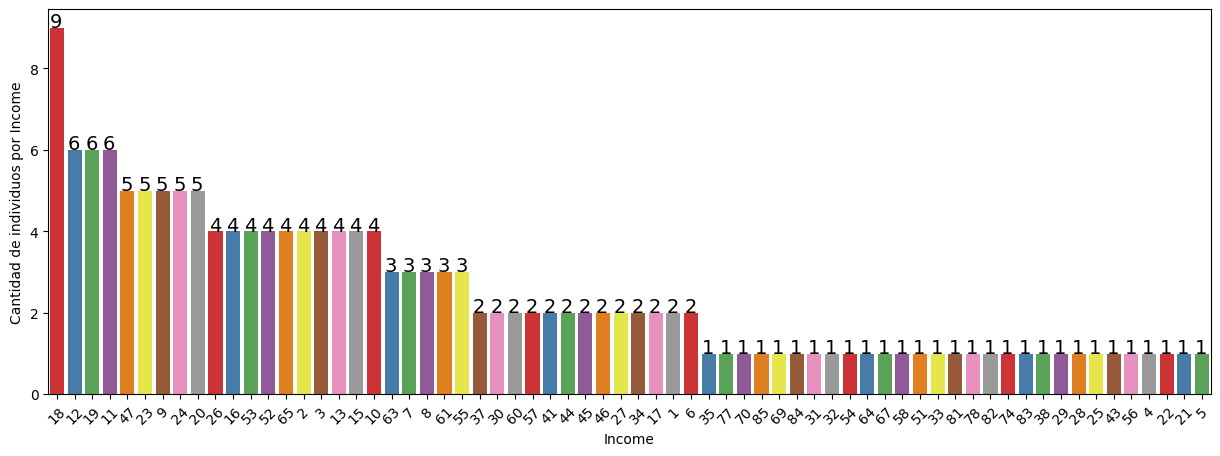

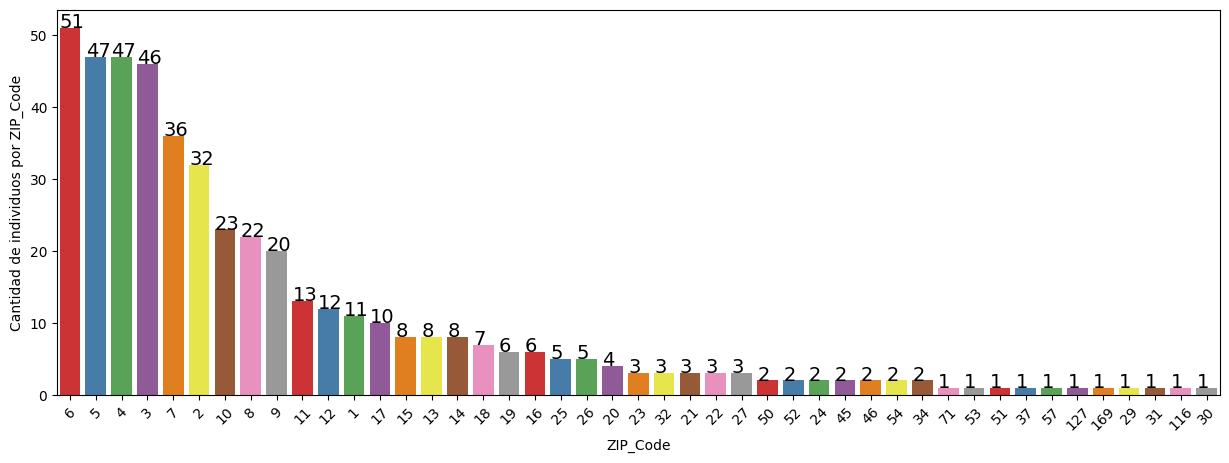

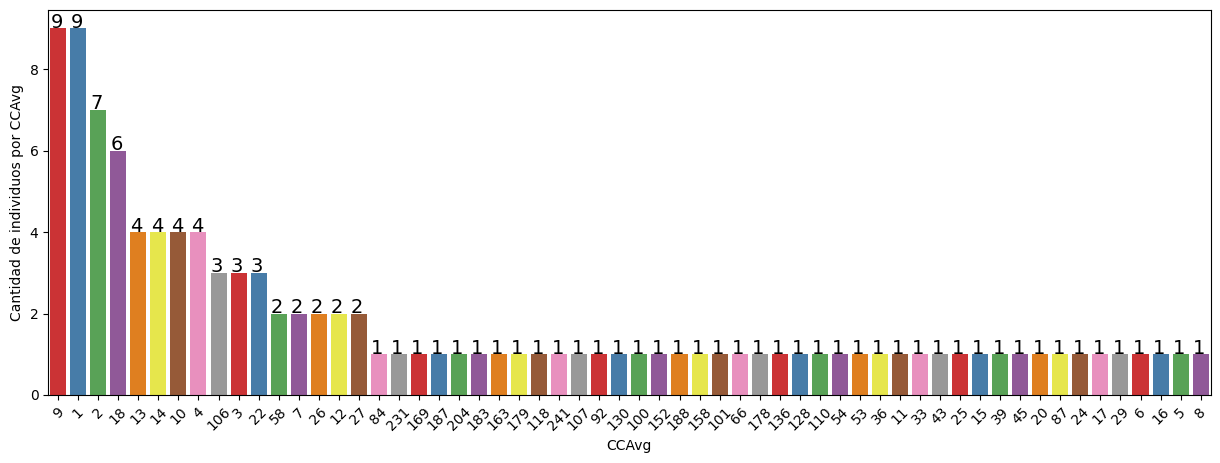

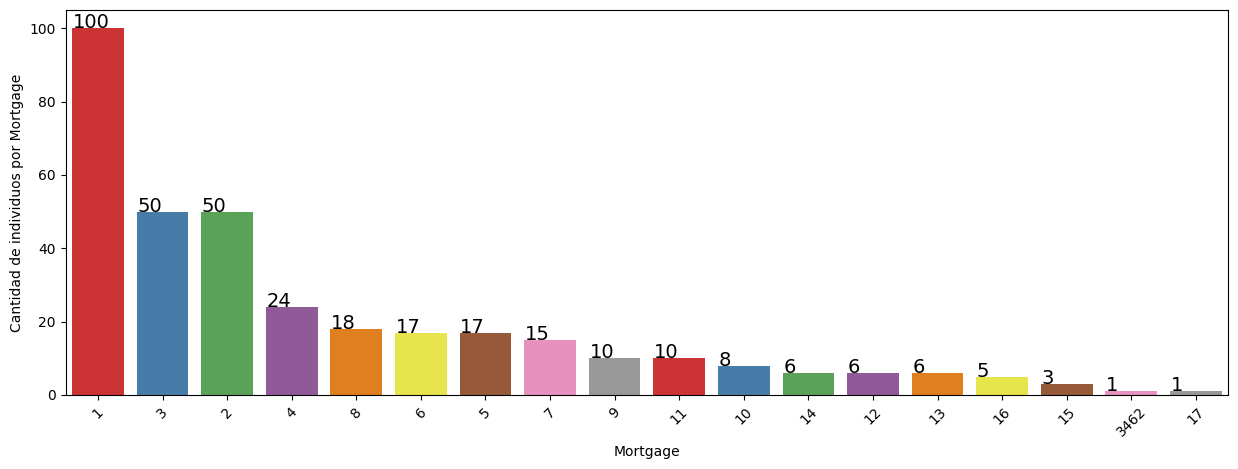

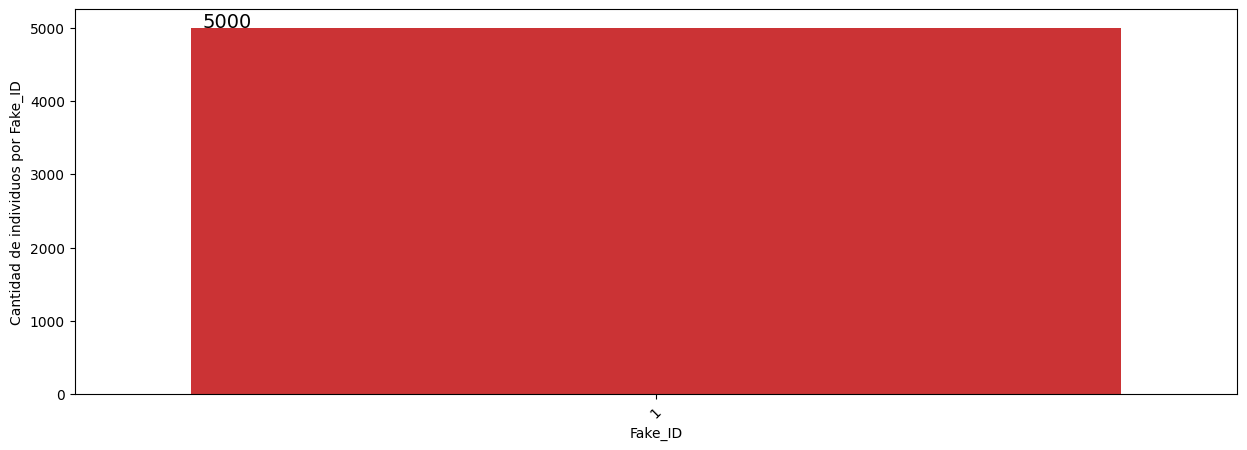

In [19]:
import warnings
warnings.filterwarnings('ignore')

#Automatizando el conteo y obtención de gráficos
casos=pd.DataFrame()
for i in data.columns.values:
  casos=pd.DataFrame(data[i].groupby(data[i]).agg('count'))
  for j in casos:
   if casos[casos[j]==1].count()[0]>0:
    print(str(j)+' '+'es variable sensible por poseer casos únicos')
    plt.figure(figsize=(15,5))
    a=sns.countplot(x=casos[i], data=casos,  order = casos[i].value_counts().index, palette="Set1" )
    a.tick_params(labelsize=10)
    for p in a.patches:
      a.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+0.01), fontsize=14)
    plt.xticks(rotation=+45)
    plt.ylabel('Cantidad de individuos por'+' '+str(i))

##**Conteo combinado para la reidentificación indirecta**

In [20]:
data.columns

Index(['Age', 'Experience', 'Income', 'ZIP_Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard', 'Fake_ID'],
      dtype='object')

In [21]:
data.groupby(['Income', 'ZIP_Code']).agg('count')

Age  Experience  Family  CCAvg  Education  Mortgage  \
Income ZIP_Code                                                        
8      90089       1           1       1      1          1         1   
       92093       1           1       1      1          1         1   
       92104       1           1       1      1          1         1   
       92612       1           1       1      1          1         1   
       92626       1           1       1      1          1         1   
...              ...         ...     ...    ...        ...       ...   
204    92780       1           1       1      1          1         1   
205    93106       1           1       1      1          1         1   
       95762       1           1       1      1          1         1   
218    91801       1           1       1      1          1         1   
224    93940       1           1       1      1          1         1   

                 Personal_Loan  Securities_Account  CD_Account  Online  \
Income ZIP_Code                                                          
8      90089                 1                   1           1       1   
       92093                 1                   1           1       1   
       92104                 1                   1           1       1   
       92612                 1                   1           1       1   
       92626                 1                   1           1       1   
...                        ...                 ...         ...     ...   
204    92780                 1                   1           1       1   
205    93106                 1                   1           1       1   
       95762                 1                   1           1       1   
218    91801                 1                   1           1       1   
224    93940                 1                   1           1       1   

                 CreditCard  Fake_ID  
Income ZIP_Code                       
8      90089              1        1  
       92093              1        1  
       92104              1        1  
       92612              1        1  
       92626              1        1  
...                     ...      ...  
204    92780              1        1  
205    93106              1        1  
       95762              1        1  
218    91801              1        1  
224    93940              1        1  

[4484 rows x 12 columns]

In [22]:
#Se agrupan los casos por CP y ZIP_Code para contarlos y determinar cuantos casos combinando ambas variables son únicos
data_1=data.groupby(['Income', 'ZIP_Code'],as_index=False).ZIP_Code.count()

Text(0, 0.5, 'Cantidad de casos')

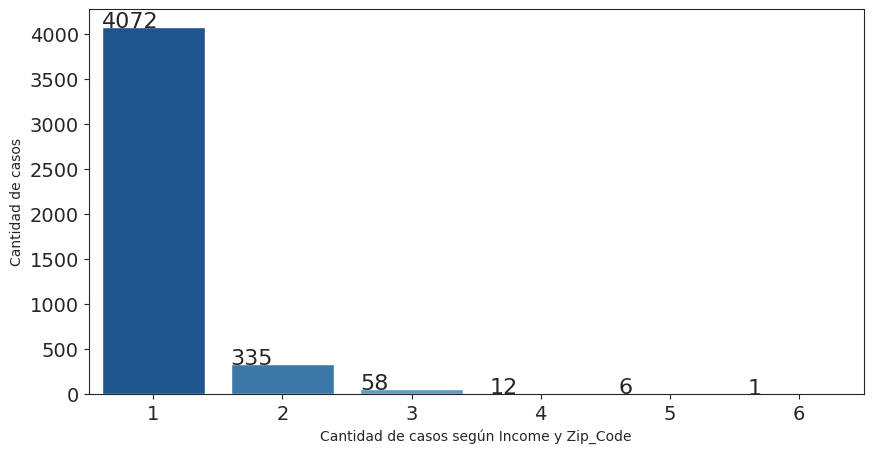

In [23]:
#se visualiza cantidad de casos según Ingreso y ZIP_Code
sns.set_style("ticks")
plt.figure(figsize=(10,5))

a=sns.countplot(x='ZIP_Code',data=data_1, palette="Blues_r")
a.tick_params(labelsize=14)

for p in a.patches:
   a.annotate('{:.0f}'.format(p.get_height()), (p.get_x(), p.get_height()), fontsize=16)


plt.xlabel("Cantidad de casos según Income y Zip_Code")
plt.ylabel("Cantidad de casos")

In [24]:
#porcentaje de casos posibles de identificar de manera unívoca combinando Income y ZIP_Code
'el {:.2f}% de individuos son posibles de identificar a partir de combinar las variables Income y ZIP_Code '.format(round(4972/len(data),4)*100)

'el 99.44% de individuos son posibles de identificar a partir de combinar las variables Income y ZIP_Code '

In [25]:
data.groupby(['Income', 'Age', 'ZIP_Code']).agg('count')

Experience  Family  CCAvg  Education  Mortgage  \
Income Age ZIP_Code                                                   
8      26  94550              1       1      1          1         1   
       31  95131              1       1      1          1         1   
       32  92093              1       1      1          1         1   
       34  94710              1       1      1          1         1   
       35  94043              1       1      1          1         1   
...                         ...     ...    ...        ...       ...   
204    46  92780              1       1      1          1         1   
205    26  93106              1       1      1          1         1   
       46  95762              1       1      1          1         1   
218    45  91801              1       1      1          1         1   
224    48  93940              1       1      1          1         1   

                     Personal_Loan  Securities_Account  CD_Account  Online  \
Income Age ZIP_Code                                                          
8      26  94550                 1                   1           1       1   
       31  95131                 1                   1           1       1   
       32  92093                 1                   1           1       1   
       34  94710                 1                   1           1       1   
       35  94043                 1                   1           1       1   
...                            ...                 ...         ...     ...   
204    46  92780                 1                   1           1       1   
205    26  93106                 1                   1           1       1   
       46  95762                 1                   1           1       1   
218    45  91801                 1                   1           1       1   
224    48  93940                 1                   1           1       1   

                     CreditCard  Fake_ID  
Income Age ZIP_Code                       
8      26  94550              1        1  
       31  95131              1        1  
       32  92093              1        1  
       34  94710              1        1  
       35  94043              1        1  
...                         ...      ...  
204    46  92780              1        1  
205    26  93106              1        1  
       46  95762              1        1  
218    45  91801              1        1  
224    48  93940              1        1  

[4984 rows x 11 columns]

In [26]:
#Se agrupan los casos por Income, Age y ZIP_Code para contarlos y determinar cuantos casos combinando las tres variables son únicos
data_2=data.groupby(['Income', 'Age', 'ZIP_Code'],as_index=False ).ZIP_Code.count()

Text(0, 0.5, 'Cantidad de casos')

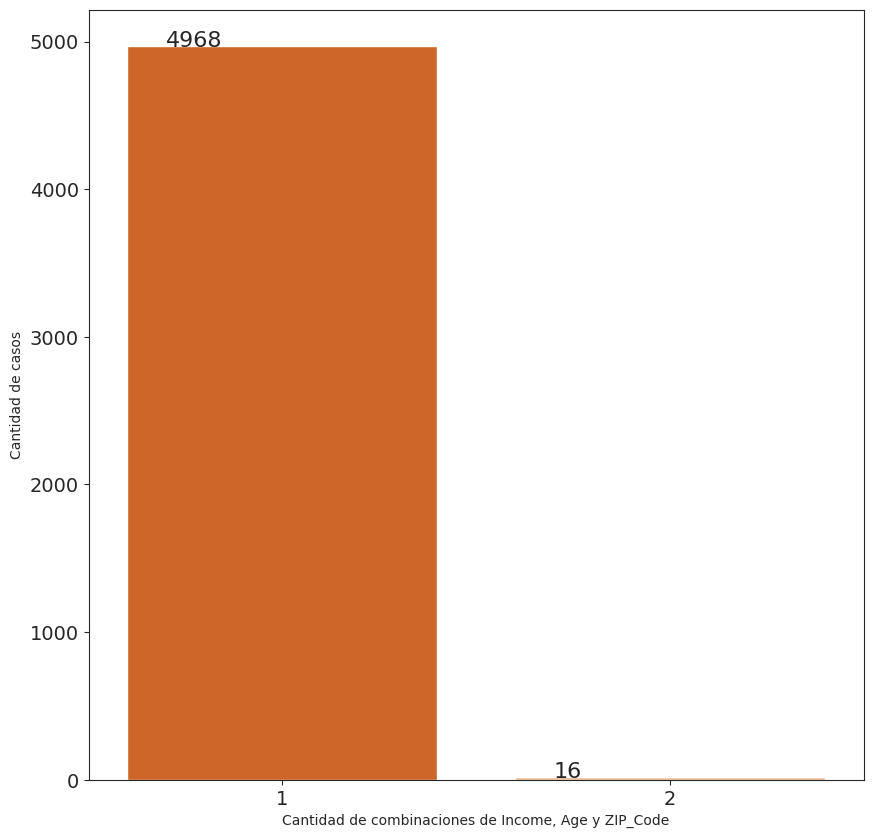

In [27]:
#se visualiza los casos según CP, EDAD y GÉNERO
plt.figure(figsize=(10,10))
sns.set_style("ticks")
a=sns.countplot(x='ZIP_Code', data=data_2, palette="Oranges_r")
a.tick_params(labelsize=14)

for p in a.patches:
   a.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.1, p.get_height()), fontsize=16)

plt.xlabel("Cantidad de combinaciones de Income, Age y ZIP_Code")
plt.ylabel("Cantidad de casos")

In [28]:
#porcentaje de casos posibles de identificar de manera unívoca
'El {:.2f}% de individuos son posibles de identificar a partir de combinar las variables Income, Age y ZIP_Code'.format(round(4968/len(data),4)*100)

'El 99.36% de individuos son posibles de identificar a partir de combinar las variables Income, Age y ZIP_Code'

## **Aplicación de Privacidad Diferencial**

In [29]:
#se instala el módulo OpenDP
!pip install opendp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 MB 22.6 MB/s eta 0:00:00


In [30]:
# se carga la librería
import opendp

In [31]:
#se genera una copia del conjunto de datos

individuos_3=data.copy()

In [32]:
#se observa
individuos_3

,Age,Experience,Income,ZIP_Code,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Fake_ID
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,KWVV43590749087981
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,WPGO81917892866997
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,IBPZ35578533259299
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,FHHF16485969271188
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,HAMQ11519078271075
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0,DBRT95690142808965
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0,HDWP98974549370590
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0,KRYL86126636347575
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0,UYSU88429374384740


In [33]:
#se verifica valores únicos de la variable ZIP_Code, sobre la cual se aplicará privacidad diferencial
pd.unique(individuos_3['ZIP_Code'])

array([91107, 90089, 94720, 94112, 91330, 92121, 91711, 93943, 93023,
       94710, 90277, 93106, 94920, 91741, 95054, 95010, 94305, 91604,
       94015, 90095, 91320, 95521, 95064, 90064, 94539, 94104, 94117,
       94801, 94035, 92647, 95814, 94114, 94115, 92672, 94122, 90019,
       95616, 94065, 95014, 91380, 95747, 92373, 92093, 94005, 90245,
       95819, 94022, 90404, 93407, 94523, 90024, 91360, 95670, 95123,
       90045, 91335, 93907, 92007, 94606, 94611, 94901, 92220, 93305,
       95134, 94612, 92507, 91730, 94501, 94303, 94105, 94550, 92612,
       95617, 92374, 94080, 94608, 93555, 93311, 94704, 92717, 92037,
       95136, 94542, 94143, 91775, 92703, 92354, 92024, 92831, 92833,
       94304, 90057, 92130, 91301, 92096, 92646, 92182, 92131, 93720,
       90840, 95035, 93010, 94928, 95831, 91770, 90007, 94102, 91423,
       93955, 94107, 92834, 93117, 94551, 94596, 94025, 94545, 95053,
       90036, 91125, 95120, 94706, 95827, 90503, 90250, 95817, 95503,
       93111, 94132,

In [34]:
#se calcula el mínimo ZIP_Code
individuos_3['ZIP_Code'].min()

9307

In [35]:
#se calcula el máximo ZIP_Code
individuos_3['ZIP_Code'].max()

96651

In [36]:
individuos_3.groupby(['ZIP_Code']).ZIP_Code.agg('count')

,ZIP_Code
ZIP_Code,
9307,1
90005,5
90007,6
90009,8
90011,3
...,...
96091,4
96094,2
96145,1


In [37]:
# se crean categorias de la variables ZIP_Code para así poder obtener gráficamente su distribución
cp_categorias = ['<= 90000' , '90001-92500', '92501-95000','95001-96651']
cut_bins = [-1, 90000, 92500, 95000, 96651] # categorias
individuos_3['ZIP_Code_2'] = pd.cut(individuos_3['ZIP_Code'], bins=cut_bins, labels=cp_categorias)

Text(0.5, 0, 'Categorías de ZIP_Code')

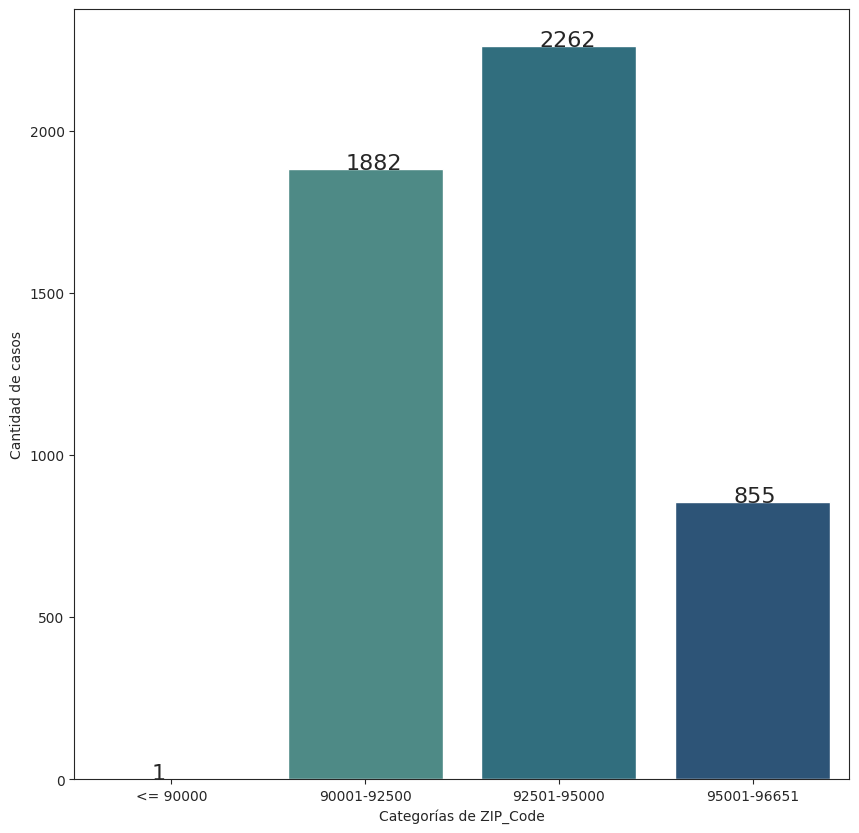

In [38]:
# se realiza un gráfico de barras según ZIP_Code para visualizar la distribución recategorizada de la variable

plt.figure(figsize=(10,10))

m=sns.countplot(x="ZIP_Code_2", data=individuos_3, palette="crest")

for p in m.patches:
   m.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()), fontsize=16)

plt.ylabel("Cantidad de casos")
plt.xlabel("Categorías de ZIP_Code")


Se genera una muestra para aplicar privacidad diferencial

In [39]:
import numpy as np
sample_size = 1000
sample = individuos_3.sample(n = sample_size, random_state=np.random.seed(2024))
sample.to_csv("samplefile.csv", index=False, header=False)

Se verifican dimensiones de la muestra

In [40]:
sample.shape

(1000, 15)

Se aplica privacidad diferencial por mecanismo de Laplace utilizando el método del histograma

In [41]:
sample.columns

Index(['Age', 'Experience', 'Income', 'ZIP_Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard', 'Fake_ID', 'ZIP_Code_2'],
      dtype='object')

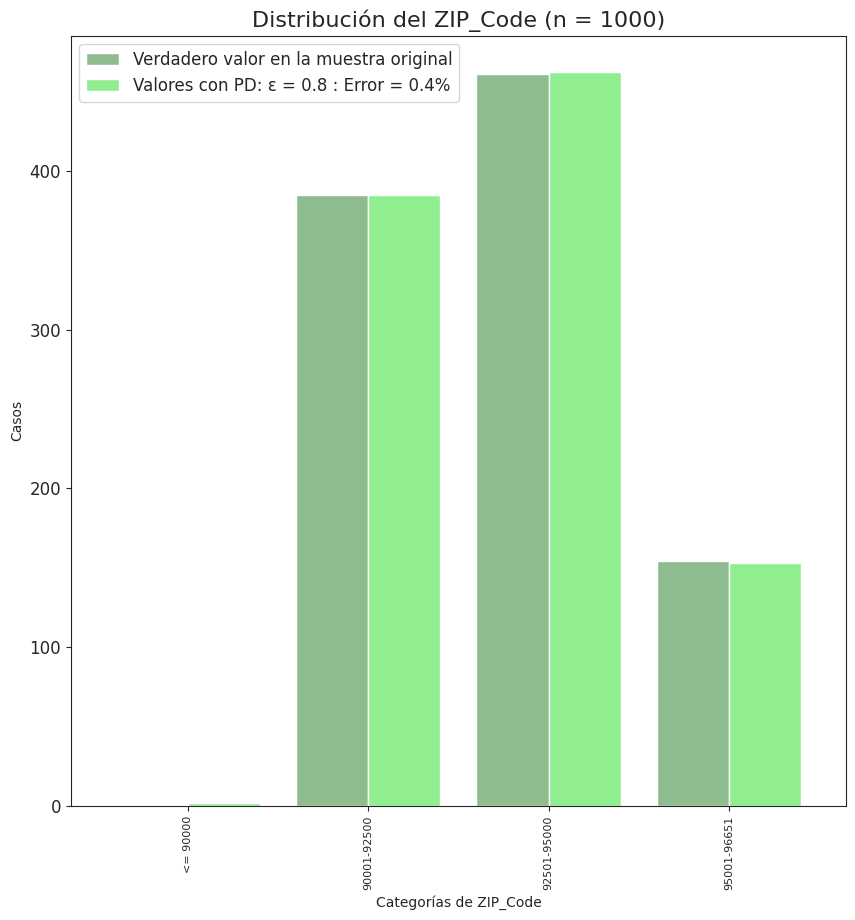

In [42]:
col_names = ['Age', 'Experience', 'Income', 'ZIP_Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard', 'Fake_ID', 'ZIP_Code_2']
categories =  ['<= 90000' , '90001-92500', '92501-95000','95001-96651']

import opendp.prelude as dp
dp.enable_features("contrib", "floating-point")
max_influence = 1
budget = (0.8, 1e-8)

with open('samplefile.csv') as input_data:
  data = input_data.read()

histogram = (
    dp.t.make_split_dataframe(separator=",", col_names=col_names) >>
    dp.t.make_select_column(key="ZIP_Code_2", TOA=str) >>
    dp.t.then_count_by_categories(categories=categories)
)


noisy_histogram = dp.binary_search_chain(lambda s: histogram >> dp.m.then_laplace(scale=s),d_in=max_influence, d_out=budget[0])

sensitive_counts = histogram(data)
np.random.seed(2024)
released_counts = noisy_histogram(data)
sens_rele= pd.DataFrame({'sensitive_counts': sensitive_counts, 'released_counts': released_counts})
sens_rele = sens_rele[:-1]

def perc_error(true_col, dp_col):
  error= sum(abs(true_col - dp_col)) / sum(true_col) * 100
  return error

error = perc_error(sens_rele['sensitive_counts'], sens_rele['released_counts'])

labels = ['Verdadero valor en la muestra original']
labels.append('Valores con PD: ε = ' + str(budget[0]) + ' : Error = ' + str(round(error,1)) + '%')

#Gráfico
colors=['darkseagreen', 'lightgreen', 'mediumseagreen', 'limegreen', 'green']
bar1=sens_rele.plot.bar(rot=45, figsize=(10, 10), width=0.8, fontsize=12, color = colors)
plt.legend(fontsize = 12, labels=labels)
plt.title('Distribución del ZIP_Code (n = '+str(sens_rele['sensitive_counts'].sum())+')', fontsize=16)
plt.xticks(np.arange(len(categories)), categories, rotation=90, fontsize=8)
plt.xlabel('Categorías de ZIP_Code')
plt.ylabel('Casos')
plt.show()

Se crea una función para aplicar PD para diferentes tamaños de muestra y valores de epsilon

In [43]:
def evaulacion(datos, sample_sizes,epsilons, categories, name_key):
  for sample_size in sample_sizes:
      sample = datos.sample(n = sample_size, random_state=np.random.seed(2024))
      sample.to_csv('samplefile.csv', index=False, header=False)

      col_names = ['Age', 'Experience', 'Income', 'ZIP_Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal_Loan', 'Securities_Account',
       'CD_Account', 'Online', 'CreditCard', 'Fake_ID', 'ZIP_Code_2']

      with open('samplefile.csv') as input_data:
        data = input_data.read()

      import opendp.prelude as dp
      dp.enable_features("contrib", "floating-point")
      max_influence = 1
      histogram = (
                        dp.t.make_split_dataframe(separator=",", col_names=col_names) >>
                        dp.t.make_select_column(key=name_key, TOA=str) >>
                        dp.t.then_count_by_categories(categories=categories)
                    )
      sensitive_counts = histogram(data)
      sens_rele= pd.DataFrame({'sensitive_counts': sensitive_counts})
      labels = ['Verdadero valor en la muestra original']
      for epsilon in epsilons:
        budget = (epsilon, 1e-8)

        noisy_histogram = dp.binary_search_chain(lambda s: histogram >> dp.m.then_laplace(scale=s),d_in=max_influence, d_out=budget[0])

        np.random.seed(2024)
        released_counts = noisy_histogram(data)
        sens_rele['Laplace-PD-'+str(epsilon)] = released_counts

        def perc_error(true_col, dp_col):
          error= sum(abs(true_col - dp_col)) / sum(true_col) * 100
          return error

        error = perc_error(sens_rele['sensitive_counts'], sens_rele['Laplace-PD-'+str(epsilon)])

        labels.append('Valores con PD: ε = ' + str(budget[0]) + ' : Error = ' + str(round(error,1)) + '%')

      #Gráfico
      sens_rele = sens_rele[:-1]
      colors=['darkseagreen', 'lightgreen', 'mediumseagreen', 'limegreen', 'green']
      bar1=sens_rele.plot.bar(rot=45, figsize=(10, 10), width=0.8, fontsize=12, color = colors)
      plt.legend(fontsize = 12, labels=labels)
      plt.title('Distribución del ZIP_Code (n = '+str(sens_rele['sensitive_counts'].sum())+')', fontsize=16)
      plt.xticks(np.arange(len(categories)), categories, rotation=90, fontsize=8)
      plt.xlabel('Categorías de ZIP_Code')
      plt.ylabel('Casos')
  return bar1

Se aplica la función creada

<Axes: title={'center': 'Distribución del ZIP_Code (n = 4950)'}, xlabel='Categorías de ZIP_Code', ylabel='Casos'>

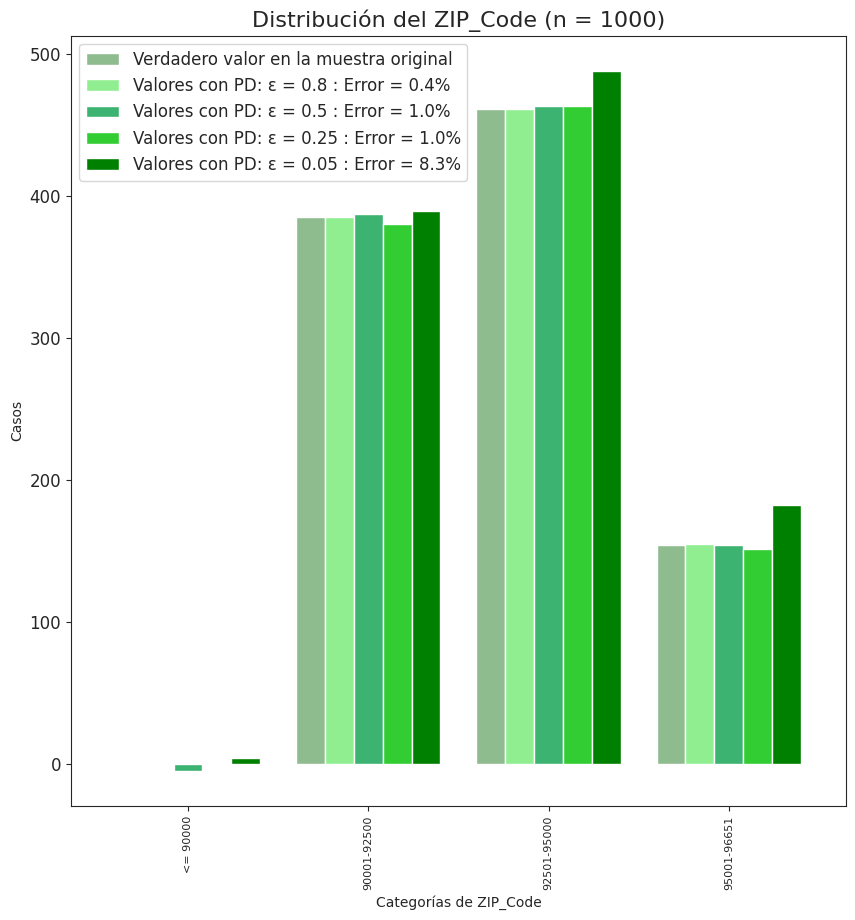

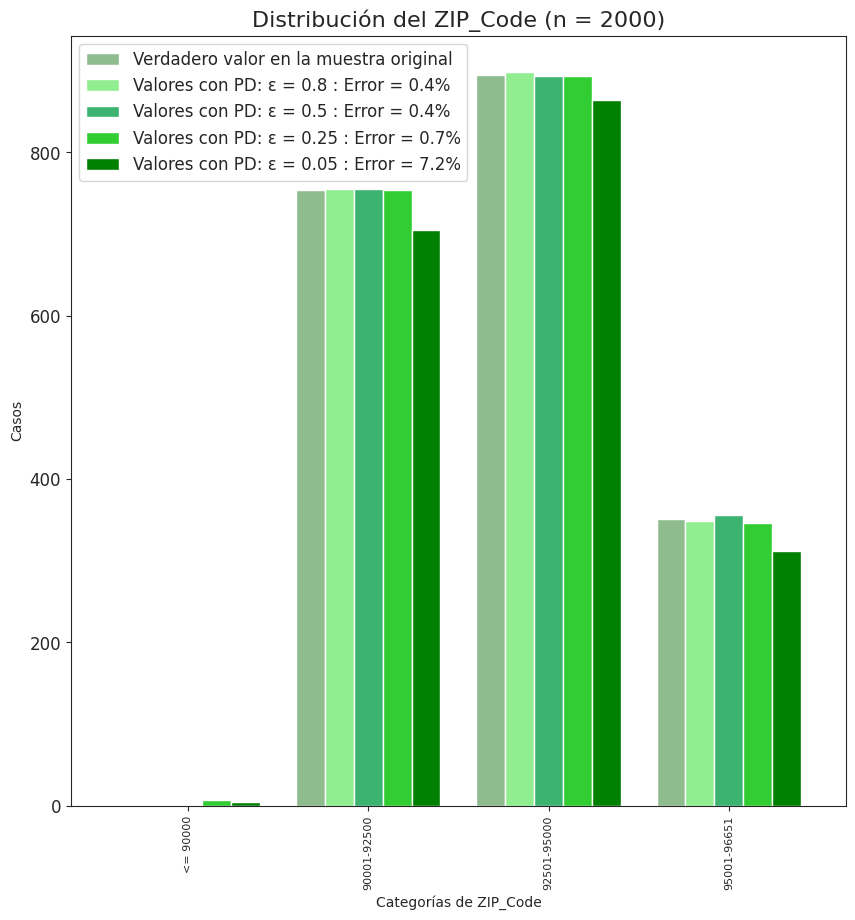

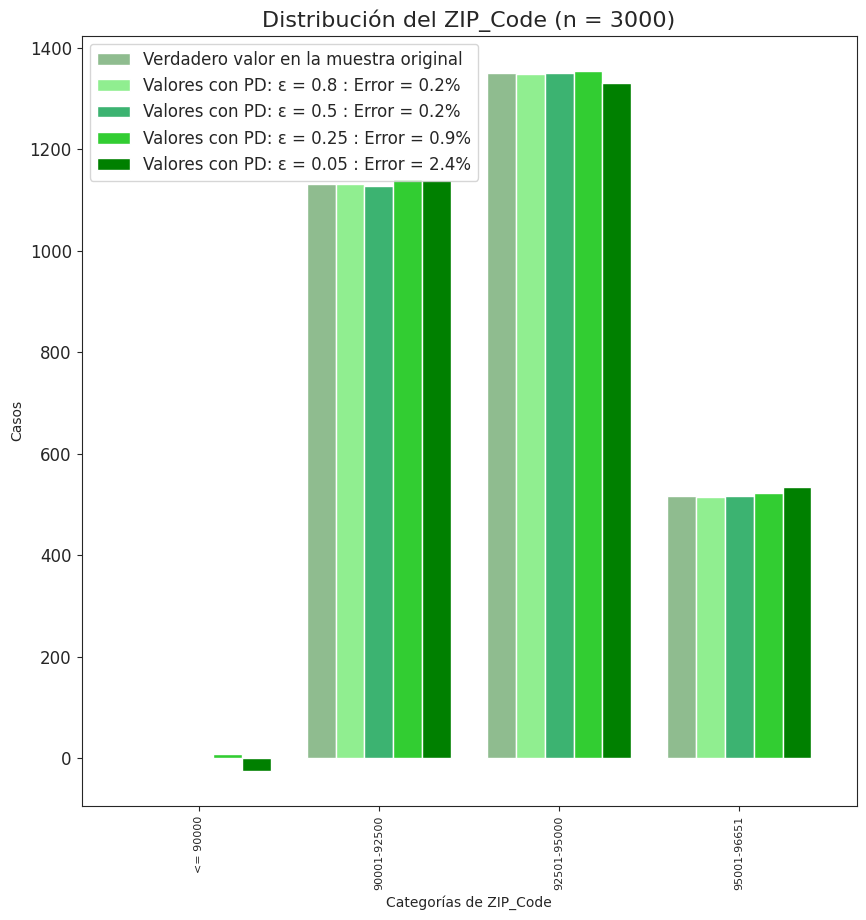

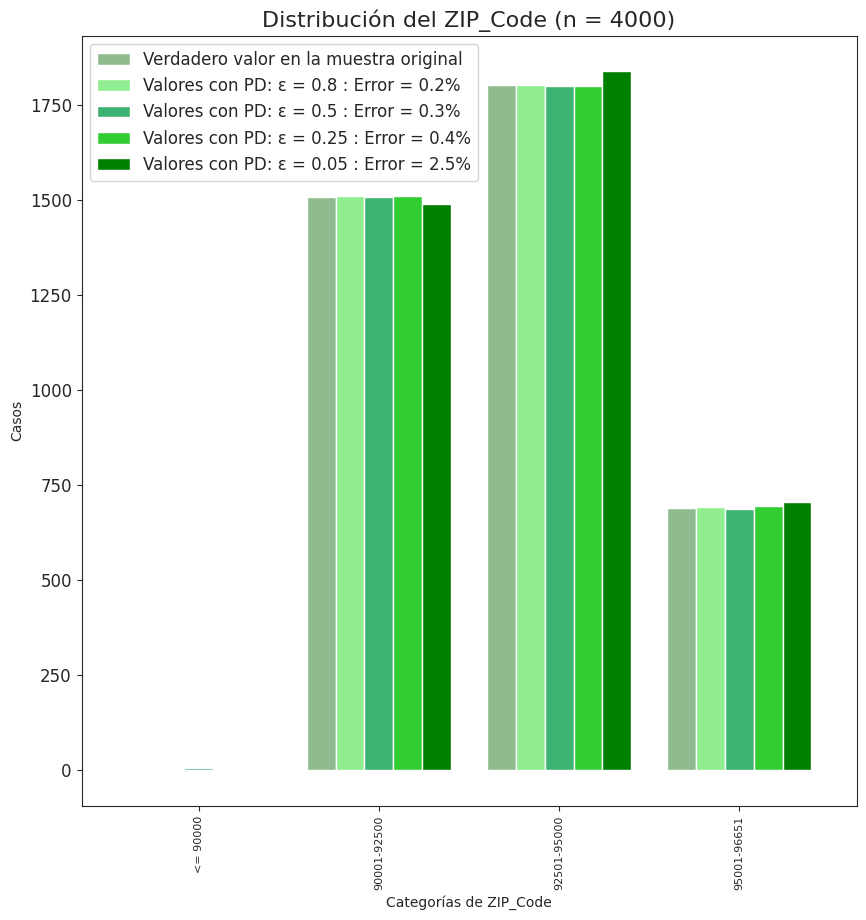

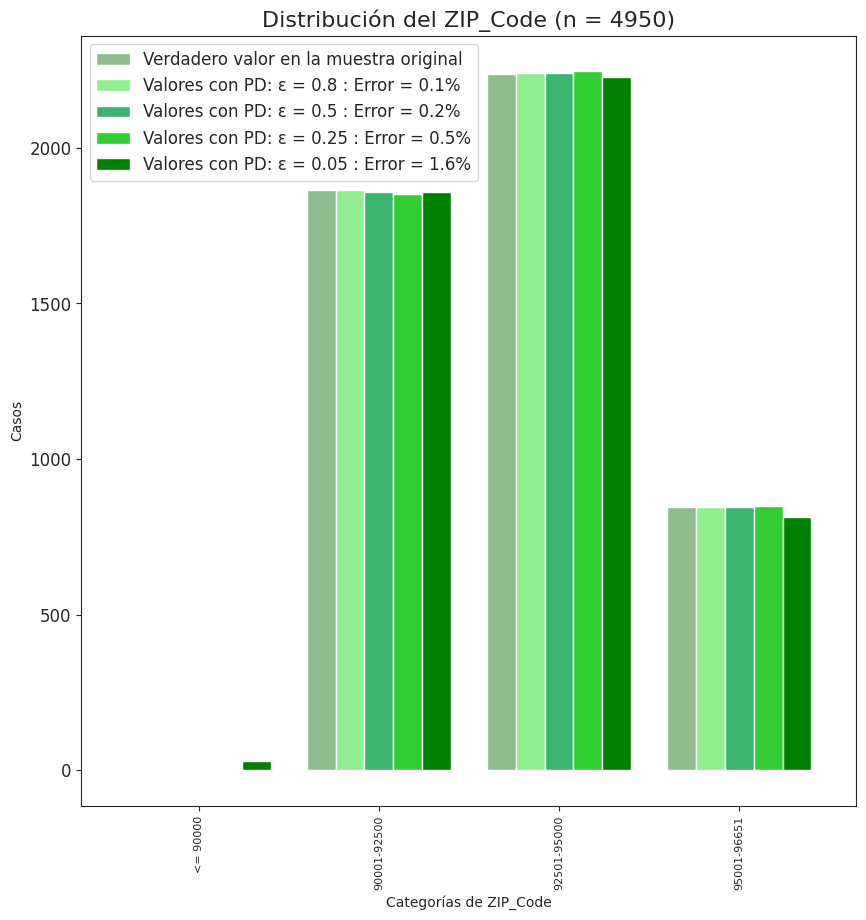

In [44]:
evaulacion(individuos_3, [1000, 2000, 3000, 4000, 4950], [0.8, 0.5, 0.25, 0.05],  ['<= 90000' , '90001-92500', '92501-95000','95001-96651'], 'ZIP_Code_2')

Conclusión:
Para cada tamaño de muestra, a medida que disminuye el valor de epsilon, es decir, a medida que se opta por reducir la pérdida de privacidad, el error aumenta. Este error representa en términos porcentuales, es la variabilidad media que existe entre el verdadero valor en la muestra y el valor obtenido de aplicar privacidad diferencial. A su vez, se observa que a medida que aumenta el tamaño de la muestra, a igual valor del parámetro epsilon, el error disminuye.

## **Implementación final de ruido aleatorio y evaluación de resultados**

**Aplicación de ruido aleatorio a la variable ZIP_Code**

In [45]:
import numpy as np
#se define una función que aplica ruido aletorio según mecanismo de Lapalce
def ruido(data, variable, variable_new, sensitivity, epsilon):
  np.random.seed(2024)
  data[variable_new]=data[variable] + np.random.laplace(loc=0, scale=sensitivity/epsilon)
  return data

In [46]:
#se aplica la función, eligiendo un epsilon de 0.25 ya de la evaluación se obtuvo un error de 0.4%.
dapar=ruido(individuos_3.copy(), 'ZIP_Code', 'ZIP_Code_2', 1, 0.25)

In [47]:
#se observa
dapar

,Age,Experience,Income,ZIP_Code,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,Fake_ID,ZIP_Code_2
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0,KWVV43590749087981,91107.77448
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0,WPGO81917892866997,90089.77448
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0,IBPZ35578533259299,94720.77448
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0,FHHF16485969271188,94112.77448
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1,HAMQ11519078271075,91330.77448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0,DBRT95690142808965,92697.77448
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0,HDWP98974549370590,92037.77448
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0,KRYL86126636347575,93023.77448
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0,UYSU88429374384740,90034.77448


In [48]:
#se observan estadísticas descriptivas de la variable ZIP_Code_2 con ruido aleatorio
dapar['ZIP_Code_2'].describe()

,ZIP_Code_2
count,5000.000000
mean,93153.277480
std,2121.852197
min,9307.774480
25%,91911.774480
50%,93437.774480
75%,94608.774480
max,96651.774480


**Evaluación de resultados**

Text(0.5, 0, 'ZIP_Code sin privacidad diferencial')

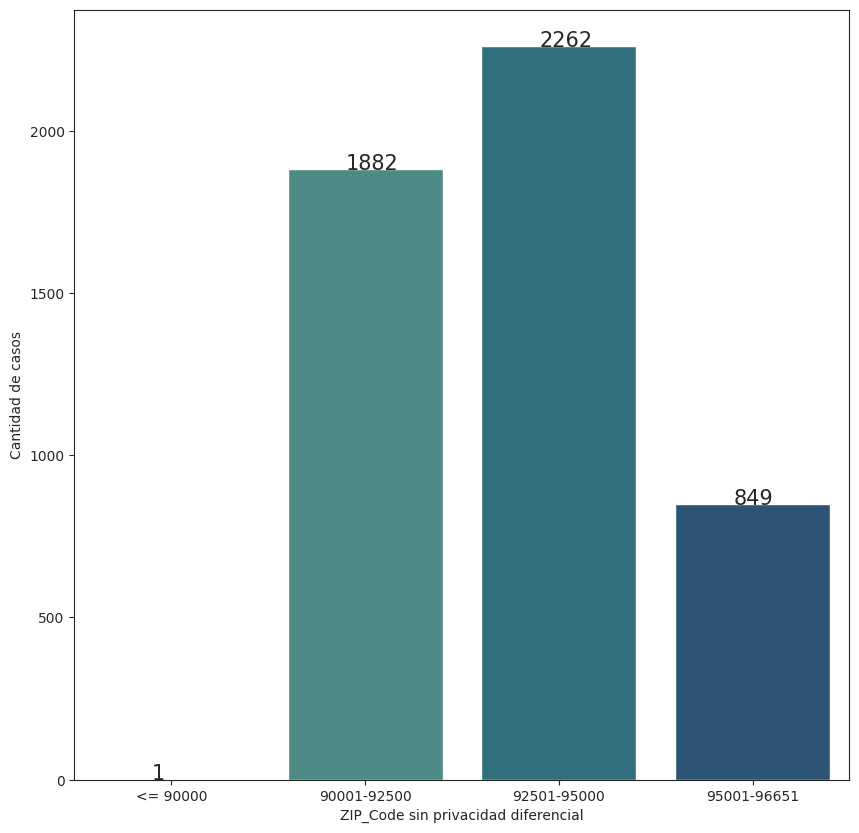

In [49]:
# Se crea una nueva variable ZIP_Code_3 recategorizando la variable ZIP_Code_2 y se visualiza
edad_categorias_2 =  ['<= 90000' , '90001-92500', '92501-95000','95001-96651']
cut_bins_2 = [-1, 90000, 92500, 95000, 96651]  # categories
dapar['ZIP_Code_3'] = pd.cut(dapar['ZIP_Code_2'], bins=cut_bins_2, labels=edad_categorias_2)

plt.figure(figsize=(10,10))
dp3=sns.countplot(x="ZIP_Code_3", data=dapar, palette="crest")
for p in dp3.patches:
   dp3.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()+0.01), fontsize=15)

plt.ylabel("Cantidad de casos")
plt.xlabel("ZIP_Code sin privacidad diferencial")

Text(0.5, 0, 'Categorías de CP con privacidad diferencial')

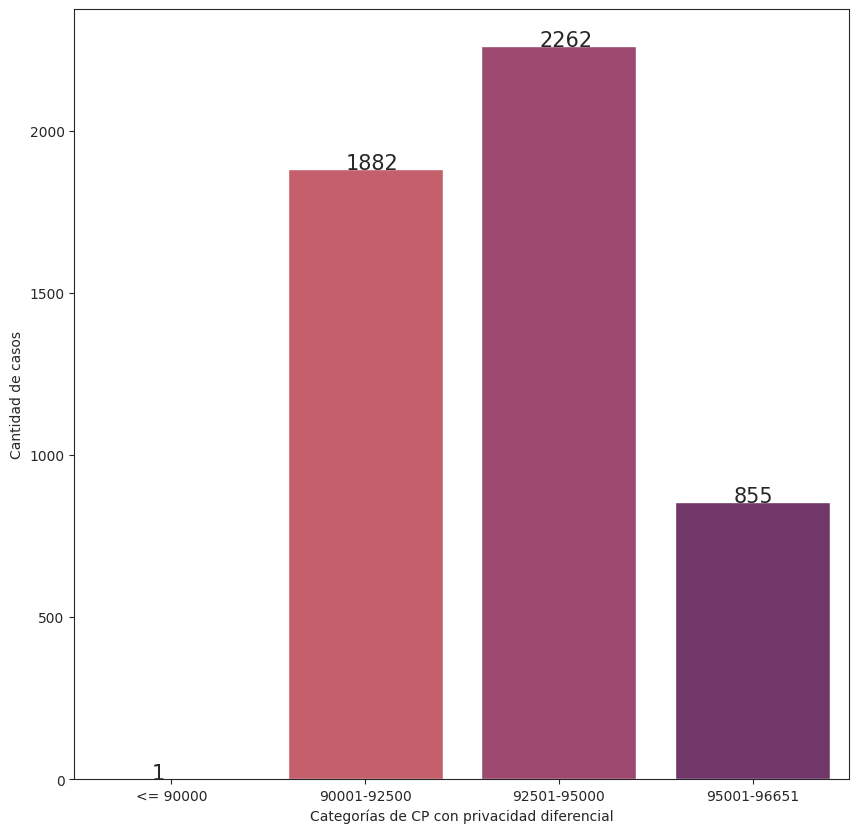

In [50]:
# Se visualiza la variable original pero recategorizada para comparar
dapar['ZIP_Code_4'] = pd.cut(dapar['ZIP_Code'], bins=cut_bins_2, labels=edad_categorias_2)

plt.figure(figsize=(10,10))
dp4=sns.countplot(x="ZIP_Code_4", data=dapar, palette="flare")
for p in dp4.patches:
   dp4.annotate('{:.0f}'.format(p.get_height()), (p.get_x()+0.3, p.get_height()), fontsize=15)

plt.ylabel("Cantidad de casos")
plt.xlabel("Categorías de CP con privacidad diferencial")

Entre ambos gráficos no se observa variación en la distribución de la variable CP recategorizada con y sin ruido aleatorio.

###**Aplicar ruido aletorio sobre Zip_Code, ¿afecta la performance de un modelo predictivo?**

In [67]:
#se importa la librería
import pandas as pd

data=pd.read_excel("/root/.cache/kagglehub/datasets/itsmesunil/bank-loan-modelling/versions/1/Bank_Personal_Loan_Modelling.xlsx", sheet_name="Data")
data.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [68]:
#se elimina la variable ID real para evitar tener el identificador directo
data=data.drop(['ID'], axis=1)

In [69]:
#se observa
data

,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [70]:
x = data.drop(['Personal Loan'], axis=1)
y = data['Personal Loan']

In [71]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [72]:
from sklearn.linear_model import LogisticRegression

In [73]:
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
y_pred_LR = logreg.predict(x_test)

In [74]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_LR)
accuracy

0.908

In [75]:
#Tomando el ZIP_Code con ruido aleatorio
individuos_4=dapar.drop(['ZIP_Code', 'Fake_ID', 'ZIP_Code_3', 'ZIP_Code_4'], axis=1)
individuos_4

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard,ZIP_Code_2
0,25,1,49,4,1.6,1,0,0,1,0,0,0,91107.77448
1,45,19,34,3,1.5,1,0,0,1,0,0,0,90089.77448
2,39,15,11,1,1.0,1,0,0,0,0,0,0,94720.77448
3,35,9,100,1,2.7,2,0,0,0,0,0,0,94112.77448
4,35,8,45,4,1.0,2,0,0,0,0,0,1,91330.77448
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,3,0,0,0,0,1,0,92697.77448
4996,30,4,15,4,0.4,1,85,0,0,0,1,0,92037.77448
4997,63,39,24,2,0.3,3,0,0,0,0,0,0,93023.77448
4998,65,40,49,3,0.5,2,0,0,0,0,1,0,90034.77448


In [76]:
x_3 = individuos_4.drop(['Personal_Loan'], axis=1)
y_3 = individuos_4['Personal_Loan']

In [77]:
from sklearn.model_selection import train_test_split

x3_train, x3_test, y3_train, y3_test = train_test_split(x_3, y_3, test_size=0.2, random_state=42)

In [78]:
from sklearn.linear_model import LogisticRegression

In [79]:
logreg = LogisticRegression()
logreg.fit(x3_train, y3_train)
y_pred_LR = logreg.predict(x3_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_LR)
accuracy

0.942

Como puede observarse no afecta la performance predictiva de un modelo ya que no fue corronpida la distribución de la variable